# Bee Haven: Bronze ➜ Silver (local version)

This notebook takes the four raw sensor CSVs from the **bronze** layer (flow, humidity, temperature, weight for the Schwartau hive),
cleans them, and writes them to the **silver** layer as Parquet files.

It follows the LMS checklist in order:

| # | LMS step | What it means for *this* data |
|---|----------|-------------------------------|
| 1 | Standardise column names | Already lowercase, but we enforce the rule with a function so future files can't break it |
| 2 | Dates & times → UTC | Timestamps are German local time (with daylight saving). Convert to UTC. Split flow into departures / arrivals |
| 3 | Fix data types | `timestamp` arrives as text → real datetime. Values must be numeric |
| 4 | Duplicates & missing data | ⚠️ Flow has 697k "duplicates" that are **not** errors. Missing values are kept as NaN (explained below) |
| 5 | Inconsistencies / units | Negative humidity and weight are impossible; check units are consistent |
| 6 | Outliers | Flow has a sensor error code (7999) and night-time spikes; we test IQR / z-score and explain why they don't fit here |
| 7 | Save as Parquet | One fixed folder layout, so the weather and gold notebooks can find the files |

**Rule of thumb for silver:** fix what is *provably wrong*, never invent data, and don't throw rows away that might matter later.

### Which chart for which question?
Every cleaning decision below is backed by a chart. The chart type is picked by the **question** we're asking:

| Question about the data | Chart type | Where it's used |
|---|---|---|
| How are the values **distributed**? Any extreme values? | **Histogram**, **box plot** | Flow values (§1, §4, §7), temperature per month (§6) |
| How does it **change over time**? Gaps? Sudden jumps? | **Line chart** | All four sensors (§1), humidity & weight before/after (§6), daily overview (§9) |
| **Compare counts** across a few categories | **Bar chart** | Missing values per file (§1), spikes per hour of day (§7), missing data per month (§8) |
| Do two measures **move together**? | **Scatter plot**, **correlation heatmap** | Silver preview (§9) |

We only use `matplotlib` (installed alongside pandas), so there's no extra package to install. `seaborn` would work too, but it isn't needed.

## 0. Setup
Paths are relative, so the notebook runs anywhere as long as this folder layout exists:
```
Bee Haven- Azure/
├── bronze/
│   ├── new/        <- the 4 raw CSVs (flow, humidity, temperature, weight)
│   └── archive/    <- raw files that have been processed (e.g. weather JSON)
├── silver/         <- created automatically: silver/flow/, silver/humidity/, ...
└── notebooks/
    └── 01_bronze_to_silver_local.ipynb
```
This is the same bronze/silver/gold layout as the Azure data lake, so moving to Synapse later is easy.
VS Code runs a notebook from its own folder, so `ROOT = Path('..')` goes up from `notebooks/` to the project folder.
When we move to Synapse later, only these paths (and `storage_options`) need to change.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path('..')                        # go up from notebooks/ to "Bee Haven- Azure"
BRONZE = ROOT / 'bronze' / 'new'        # where the 4 raw CSVs are
SILVER = ROOT / 'silver'                 # cleaned Parquet files are written here
PLACE = 'schwartau'
LOCAL_TZ = 'Europe/Berlin'               # the hive loggers record German wall-clock time

SENSORS = ['flow', 'humidity', 'temperature', 'weight']

# quick check that the notebook can see the files
for s in SENSORS:
    print(s, (BRONZE / f'{s}_{PLACE}.csv').exists())

# ---- one consistent chart style for the whole notebook ----
BLUE, ORANGE, AQUA, RED, GREY = '#2a78d6', '#eb6834', '#1baf7a', '#d03b3b', '#898781'
# BLUE = normal/clean data · ORANGE = departures · AQUA = arrivals · RED = problem values · GREY = reference lines
plt.rcParams.update({
    'figure.figsize': (12, 4), 'figure.dpi': 100,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelcolor': '#52514e', 'xtick.color': '#52514e', 'ytick.color': '#52514e',
    'lines.linewidth': 1.2, 'legend.frameon': False,
})

flow True
humidity True
temperature True
weight True


## 1. Load the raw data and look at it
**Why:** before cleaning anything we need to *see* what's wrong. We deliberately read everything as-is
(no `parse_dates`) so we can check the raw types, too.

In [2]:
raw = {s: pd.read_csv(BRONZE / f'{s}_{PLACE}.csv') for s in SENSORS}

for name, df in raw.items():
    print(f"--- {name}: {df.shape[0]:,} rows, columns={list(df.columns)}, dtypes={df.dtypes.astype(str).to_dict()}")

--- flow: 2,513,836 rows, columns=['timestamp', 'flow'], dtypes={'timestamp': 'str', 'flow': 'int64'}
--- humidity: 1,761 rows, columns=['timestamp', 'humidity'], dtypes={'timestamp': 'str', 'humidity': 'float64'}
--- temperature: 253,430 rows, columns=['timestamp', 'temperature'], dtypes={'timestamp': 'str', 'temperature': 'float64'}
--- weight: 1,761 rows, columns=['timestamp', 'weight'], dtypes={'timestamp': 'str', 'weight': 'float64'}


In [3]:
# One quick "health report" per file
def profile(df, value_col):
    v = df[value_col]
    return pd.Series({
        'rows': len(df),
        'missing values': v.isna().sum(),
        'exact duplicate rows': df.duplicated().sum(),
        'duplicate timestamps': df['timestamp'].duplicated().sum(),
        'negative values': (v < 0).sum(),
        'min': v.min(), 'max': v.max(),
        'timestamps sorted?': pd.to_datetime(df['timestamp']).is_monotonic_increasing,
    })

pd.DataFrame({name: profile(df, name) for name, df in raw.items()})

,flow,humidity,temperature,weight
rows,2513836,1761,253430,1761
missing values,0,12,2032,12
exact duplicate rows,697348,0,0,0
duplicate timestamps,1257038,0,24,0
negative values,543449,31,4033,37
min,-631,-100.0,-7.26,-172.44
max,7999,100.0,37.53,92042.23
timestamps sorted?,False,True,False,True


**What the report tells us**
- `timestamp` is stored as text (object/string) → must become a datetime.
- **flow** has 2.5M rows but ~half the timestamps are duplicated, and it isn't sorted → the file is two series glued together.
- **humidity** and **weight** have negative values → physically impossible.
- **temperature** has 24 duplicate timestamps → suspicious, we'll see it's daylight saving time.
- All four files have some missing values.

### 1b. Visual first look
Numbers in a table are easy to skim past. Charts make the problems jump out.

**Bar chart: how much is missing per file?** A bar chart is the right tool for *comparing one number across a few categories*.
We use **percent** instead of raw counts because the files have very different sizes (1,761 vs 2.5M rows).

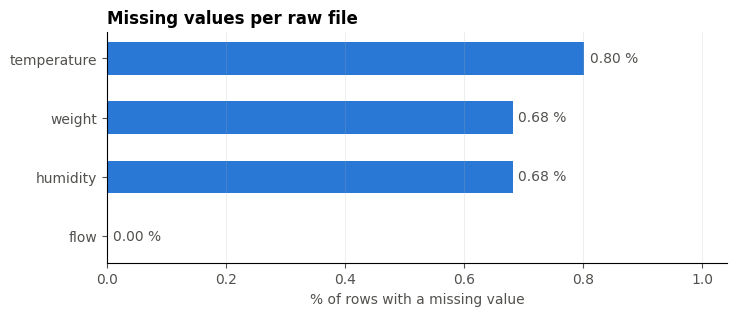

In [4]:
missing_pct = pd.Series({name: df[name].isna().mean() * 100 for name, df in raw.items()}).sort_values()

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(missing_pct.index, missing_pct.values, color=BLUE, height=0.55)
ax.bar_label(bars, labels=[f'{v:.2f} %' for v in missing_pct.values], padding=4, color='#52514e')
ax.set_xlabel('% of rows with a missing value')
ax.set_title('Missing values per raw file')
ax.grid(axis='y', visible=False)
ax.set_xlim(0, missing_pct.max() * 1.3)
plt.show()

Less than 1 % is missing in every file, so no file is broken. We'll look at *where* the gaps are in §8.

**Line charts: every sensor over time.** A line chart answers *"how does it change over time?"* and shows impossible values,
jumps and gaps at a glance. Values below zero are marked in red, since for humidity and weight they're impossible.

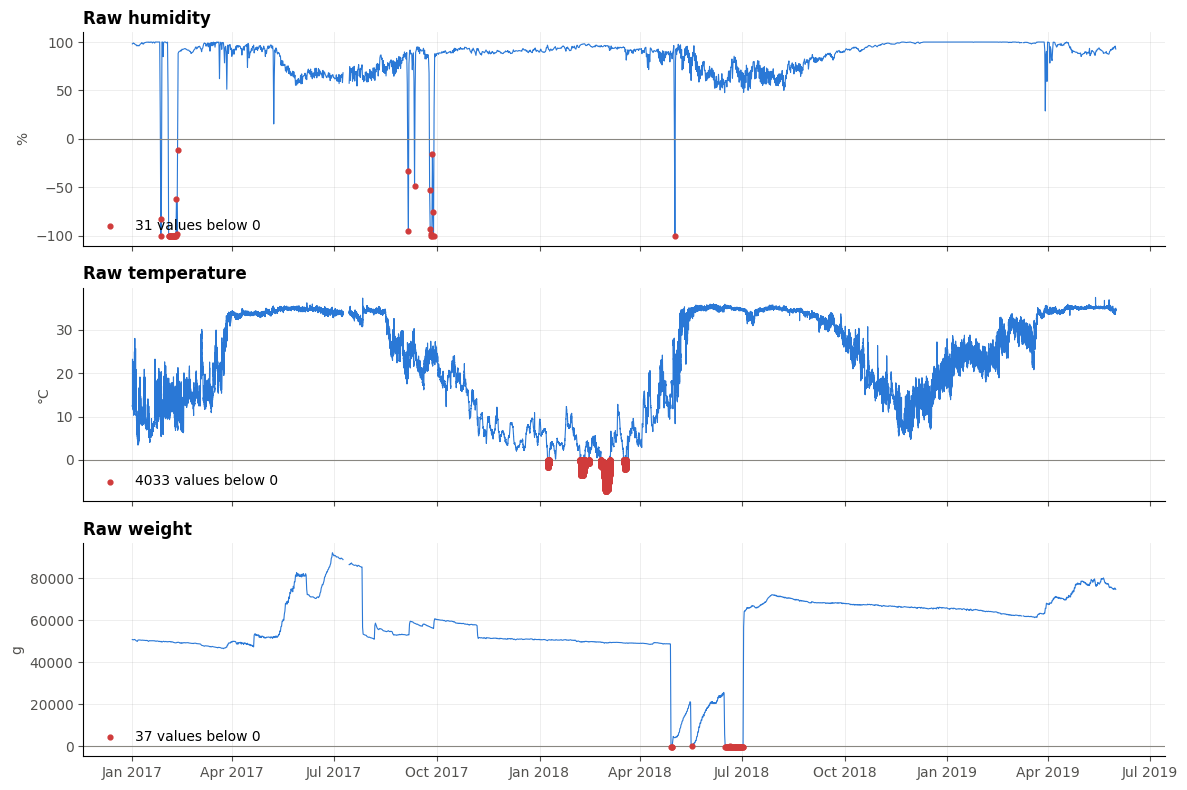

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, (name, unit) in zip(axes, [('humidity', '%'), ('temperature', '°C'), ('weight', 'g')]):
    df = raw[name].assign(timestamp=pd.to_datetime(raw[name]['timestamp']))
    ax.plot(df['timestamp'], df[name], color=BLUE, linewidth=0.8)
    neg = df[df[name] < 0]
    ax.scatter(neg['timestamp'], neg[name], color=RED, s=12, zorder=3, label=f'{len(neg)} values below 0')
    ax.axhline(0, color=GREY, linewidth=0.8)
    ax.set_ylabel(unit)
    ax.set_title(f'Raw {name}')
    ax.legend(loc='lower left')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout(); plt.show()

What we see:
- **Humidity** occasionally drops to −100, which is physically impossible (§6).
- **Temperature** negatives are clustered in winter, which is plausible (§6).
- **Weight** falls to about zero in spring 2018, dips slightly *below* zero, then climbs again. That's an empty hive, not a sensor error (§6).

**Flow is different**, so we plot it against its *row number* instead of time. This shows how the file is organised:

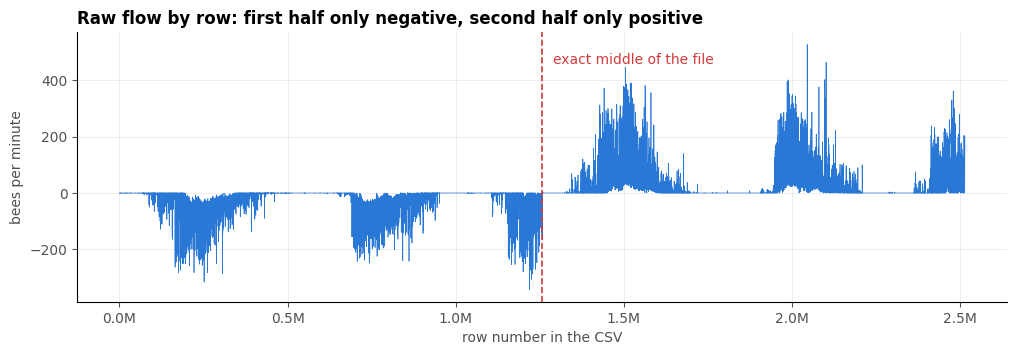

In [6]:
f = raw['flow'].iloc[::50]            # every 50th row is plenty to see the shape (50k points instead of 2.5M)
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(f.index, f['flow'], color=BLUE, linewidth=0.5)
ax.axvline(len(raw['flow']) // 2, color=RED, linestyle='--', linewidth=1.2)
ax.annotate('exact middle of the file', xy=(len(raw['flow']) // 2, ax.get_ylim()[1] * 0.8),
            xytext=(8, 0), textcoords='offset points', color=RED)
ax.set_xlabel('row number in the CSV'); ax.set_ylabel('bees per minute')
ax.set_title('Raw flow by row: first half only negative, second half only positive')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.show()

That picture is the reason for §4: the file is two series stacked on top of each other.

## 2. Standardise column names
**Why:** in a lake many files from different sources get joined together. If one file says `Hive ID` and another `hive_id`,
joins silently fail. We apply one rule everywhere: lowercase, underscores, no special characters.
Our columns are already clean, but running the function makes the pipeline safe for the next location's files (e.g. Würzburg).

In [7]:
def standardise_columns(df):
    df = df.copy()
    df.columns = [
        re.sub(r'_+', '_', re.sub(r'[^0-9a-z]+', '_', col.strip().lower())).strip('_')
        for col in df.columns
    ]
    return df

# quick demo on messy names
print(standardise_columns(pd.DataFrame(columns=['Time Stamp', 'Hive-ID', 'Weight (g)'])).columns.tolist())

raw = {name: standardise_columns(df) for name, df in raw.items()}
{name: list(df.columns) for name, df in raw.items()}

['time_stamp', 'hive_id', 'weight_g']


{'flow': ['timestamp', 'flow'],
 'humidity': ['timestamp', 'humidity'],
 'temperature': ['timestamp', 'temperature'],
 'weight': ['timestamp', 'weight']}

## 3. Fix data types
**Why:** a timestamp stored as text can't be sorted chronologically, compared or converted to UTC.
Numbers stored as text can't be averaged. `errors='coerce'` turns anything unparseable into NaN, and we *count* those
so we'd notice if a stray string like `"n/a"` had been hiding in the column.

In [8]:
def fix_types(df, value_col):
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
    before_na = df[value_col].isna().sum()
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
    print(f"{value_col:12s} unparseable timestamps: {df['timestamp'].isna().sum()}, "
          f"text values turned into NaN: {df[value_col].isna().sum() - before_na}")
    return df

typed = {name: fix_types(df, name) for name, df in raw.items()}

flow         unparseable timestamps: 0, text values turned into NaN: 0
humidity     unparseable timestamps: 0, text values turned into NaN: 0
temperature  unparseable timestamps: 0, text values turned into NaN: 0
weight       unparseable timestamps: 0, text values turned into NaN: 0


Nothing was hidden as text: the numbers were already numeric. Good, but now we *know* it rather than assume it.

## 4. Flow: split departures and arrivals
**Why:** the flow file lists every minute **twice**. Looking at the data:
the first half holds only values ≤ 0 (bees *leaving*), the second half only values ≥ 0 (bees *arriving*),
and both halves cover exactly the same timestamps in the same order.
If we left it like this, one timestamp would have two meanings. So we split and put them side by side:
`flow_out` and `flow_in`, which makes the departure/arrival distinction explicit (as the LMS asks).

We **prove** each assumption rather than trust it.

In [9]:
flow = typed['flow']
half = len(flow) // 2
departures = flow.iloc[:half].reset_index(drop=True)
arrivals   = flow.iloc[half:].reset_index(drop=True)

print('even number of rows:          ', len(flow) % 2 == 0)
print('same timestamps in both halves:', (departures['timestamp'].values == arrivals['timestamp'].values).all())
print('departures all <= 0:           ', (departures['flow'] <= 0).all())
print('arrivals all >= 0:             ', (arrivals['flow'] >= 0).all())

even number of rows:           True
same timestamps in both halves: True
departures all <= 0:            True
arrivals all >= 0:              True


**Histograms: departures vs arrivals.** A histogram answers *"what values occur, and how often?"*.
The y-axis is **logarithmic** because ~60 % of all minutes are exactly 0 (night, winter). On a normal axis that one bar
would squash everything else flat. On a log scale every step up (1 → 10 → 100 …) is ten times more minutes.

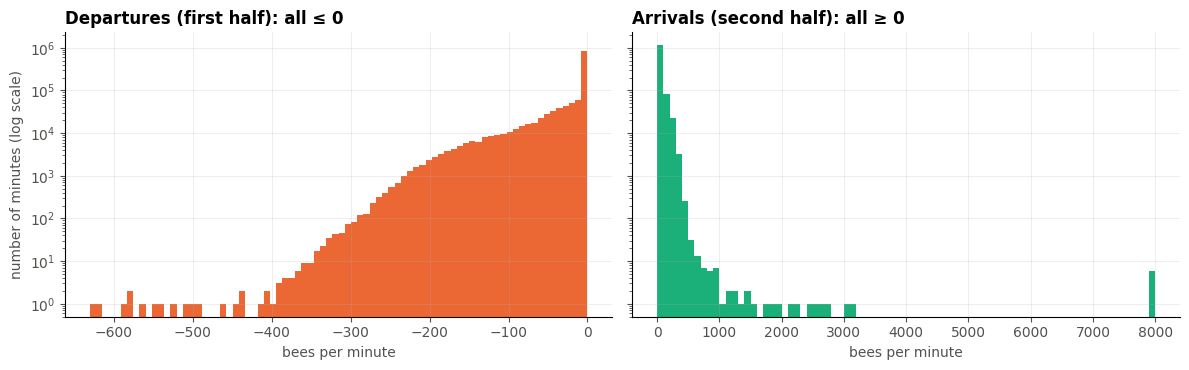

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
axes[0].hist(departures['flow'], bins=80, color=ORANGE)
axes[0].set_title('Departures (first half): all ≤ 0')
axes[1].hist(arrivals['flow'], bins=80, color=AQUA)
axes[1].set_title('Arrivals (second half): all ≥ 0')
for ax in axes:
    ax.set_yscale('log'); ax.set_xlabel('bees per minute')
axes[0].set_ylabel('number of minutes (log scale)')
plt.tight_layout(); plt.show()

The two halves are near mirror images: same shape, opposite sign. That confirms the split.
Notice the arrivals axis stretches all the way to **~8,000** while departures stop at about −630. We come back to that in §7.

### Why we must NOT run `drop_duplicates()` on raw flow
`flow.duplicated()` reports ~697k "exact duplicate rows". They aren't errors: at night the departure *and* arrival counts are both 0,
so `(timestamp, 0)` appears once in each half. Blindly dropping them would delete real measurements.
Lesson: *always understand why a duplicate exists before removing it.*

In [11]:
print('exact duplicates in raw flow:', flow.duplicated().sum())
print('of which have flow == 0:     ', flow[flow.duplicated()]['flow'].eq(0).sum())

exact duplicates in raw flow: 697348


of which have flow == 0:      697348


## 5. Convert all timestamps to UTC
**Why:** the loggers write German wall-clock time. Twice a year that clock jumps:
- **October** (clocks go back): 02:00–02:59 happens **twice** → duplicate timestamps (that's the 24 temperature duplicates, and why flow isn't sorted).
- **March** (clocks go forward): 02:00–02:59 never happens.

UTC never jumps, so every real moment gets exactly one timestamp. The weather API also returns UTC, so this is what makes the later join correct.

`tz_localize` needs to know what to do with the repeated October hour:
- **flow & temperature** (every 1 or 5 min): `ambiguous='infer'`. Pandas sees the sequence 02:58, 02:59, 02:00, 02:01 … and works out which is summer and which is winter time.
- **humidity & weight** (every 12 h): only one reading lands in the repeated hour, so there's nothing to infer from. Looking at the October dates shows those readings sit **before** the clock change → `ambiguous=True` (= summer time).

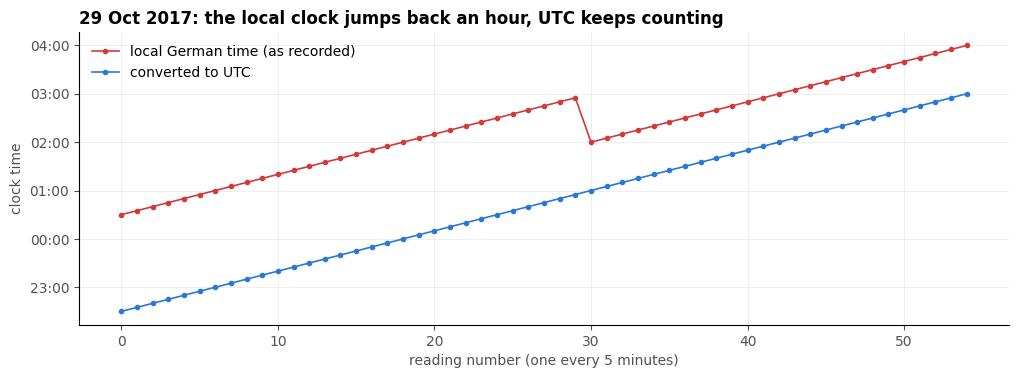

departures   duplicate timestamps after UTC: 0
arrivals     duplicate timestamps after UTC: 0
humidity     duplicate timestamps after UTC: 0
temperature  duplicate timestamps after UTC: 0
weight       duplicate timestamps after UTC: 0


In [12]:
def to_utc(ts, ambiguous):
    return ts.dt.tz_localize(LOCAL_TZ, ambiguous=ambiguous).dt.tz_convert('UTC')

# --- Line chart: what happens at the October clock change? (temperature, night of 28/29 Oct 2017) ---
t = typed['temperature']
window = t[(t['timestamp'] >= '2017-10-29 00:30') & (t['timestamp'] <= '2017-10-29 04:00')].copy()
window['utc'] = to_utc(t['timestamp'], 'infer').loc[window.index].dt.tz_localize(None)
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(range(len(window)), window['timestamp'], color=RED, marker='o', markersize=3, label='local German time (as recorded)')
ax.plot(range(len(window)), window['utc'], color=BLUE, marker='o', markersize=3, label='converted to UTC')
ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel('reading number (one every 5 minutes)'); ax.set_ylabel('clock time')
ax.set_title('29 Oct 2017: the local clock jumps back an hour, UTC keeps counting')
ax.legend(loc='upper left')
plt.show()

departures['timestamp'] = to_utc(departures['timestamp'], 'infer')
arrivals['timestamp']   = to_utc(arrivals['timestamp'], 'infer')

humidity    = typed['humidity'].copy();    humidity['timestamp']    = to_utc(humidity['timestamp'], True)
weight      = typed['weight'].copy();      weight['timestamp']      = to_utc(weight['timestamp'], True)
temperature = typed['temperature'].copy(); temperature['timestamp'] = to_utc(temperature['timestamp'], 'infer')

for name, df in [('departures', departures), ('arrivals', arrivals), ('humidity', humidity),
                 ('temperature', temperature), ('weight', weight)]:
    print(f"{name:12s} duplicate timestamps after UTC: {df['timestamp'].duplicated().sum()}")

All duplicate timestamps are gone: they were only ever a daylight-saving effect. Now reassemble flow:

In [13]:
flow_clean = (departures.rename(columns={'flow': 'flow_out'})
              .merge(arrivals.rename(columns={'flow': 'flow_in'}), on='timestamp', how='inner', validate='one_to_one'))
print(len(flow_clean), 'rows (should be', half, ')')
flow_clean.head()

1256918 rows (should be 1256918 )


,timestamp,flow_out,flow_in
0,2017-01-01 13:15:00+00:00,0,0
1,2017-01-01 13:16:00+00:00,0,0
2,2017-01-01 13:17:00+00:00,0,0
3,2017-01-01 13:18:00+00:00,0,0
4,2017-01-01 13:19:00+00:00,0,0


Note: `flow_out` stays **negative** (e.g. −22 = 22 bees left). We keep the sign so departures and arrivals can never be mixed up; gold turns them into positive counts.
`validate='one_to_one'` makes pandas raise an error if any timestamp were still duplicated. It's a cheap safety net.

## 6. Impossible values (inconsistencies)
### Humidity: negative values
Relative humidity is 0–100 %. We find 31 negative readings, many exactly **−100** right next to readings of **100**.
That's a sign flip from the sensor, not a real value, so the absolute value restores the true reading.

In [14]:
print('negative humidity readings:', (humidity['humidity'] < 0).sum())
display(typed['humidity'].loc[48:54])                   # context: 100, 100, 23, -100, -82, 100 ...
humidity['humidity'] = humidity['humidity'].abs()
print('range after fix:', humidity['humidity'].min(), '-', humidity['humidity'].max())

negative humidity readings: 31


,timestamp,humidity
48,2017-01-25 13:00:00,100.00
49,2017-01-26 01:00:00,100.00
50,2017-01-26 13:00:00,23.06
51,2017-01-27 01:00:00,-100.00
52,2017-01-27 13:00:00,-82.25
53,2017-01-28 01:00:00,100.00
54,2017-01-28 13:00:00,99.99


range after fix: 11.19 - 100.0


**Before/after line chart.** Putting the raw and fixed series one above the other lets you check that the fix produces a believable curve.

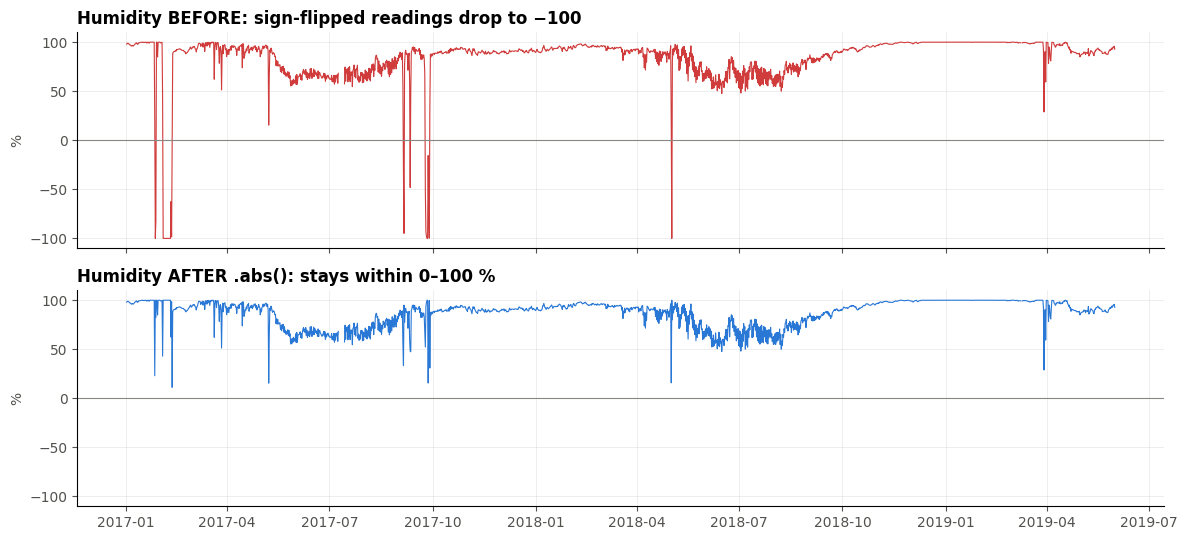

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True, sharey=True)
axes[0].plot(humidity['timestamp'], typed['humidity']['humidity'].values, color=RED, linewidth=0.8)
axes[0].set_title('Humidity BEFORE: sign-flipped readings drop to −100')
axes[1].plot(humidity['timestamp'], humidity['humidity'], color=BLUE, linewidth=0.8)
axes[1].set_title('Humidity AFTER .abs(): stays within 0–100 %')
for ax in axes:
    ax.axhline(0, color=GREY, linewidth=0.8); ax.set_ylabel('%')
plt.tight_layout(); plt.show()

### Weight: negative values
The hive normally weighs 40–90 kg (values are in **grams**). The negatives are about −100 to −170 g and occur in blocks
(Apr–Jun 2018) **right after the weight drops from ~48 kg to ~0**, then slowly climbs again.
So the hive was empty or off the scale, and the empty scale drifted slightly below zero.
The honest value is "≈ 0 g", so we **clip at 0**.

In [16]:
display(typed['weight'].loc[960:968])                     # 48,589 g ... then -170 g, then rebuilding
print('negative weight readings:', (weight['weight'] < 0).sum())
weight['weight'] = weight['weight'].clip(lower=0)

,timestamp,weight
960,2018-04-26 14:00:00,48770.66
961,2018-04-27 02:00:00,48657.81
962,2018-04-27 14:00:00,48778.57
963,2018-04-28 02:00:00,48589.74
964,2018-04-28 14:00:00,-170.61
965,2018-04-29 02:00:00,-172.44
966,2018-04-29 14:00:00,-167.10
967,2018-04-30 02:00:00,2431.76
968,2018-04-30 14:00:00,4646.91


negative weight readings: 37


**Line chart with a zoom.** Over the full period the negatives are invisible (−170 g next to 90,000 g).
Zooming into spring 2018 shows the story: the hive is emptied, the empty scale reads slightly below 0, then the colony rebuilds.

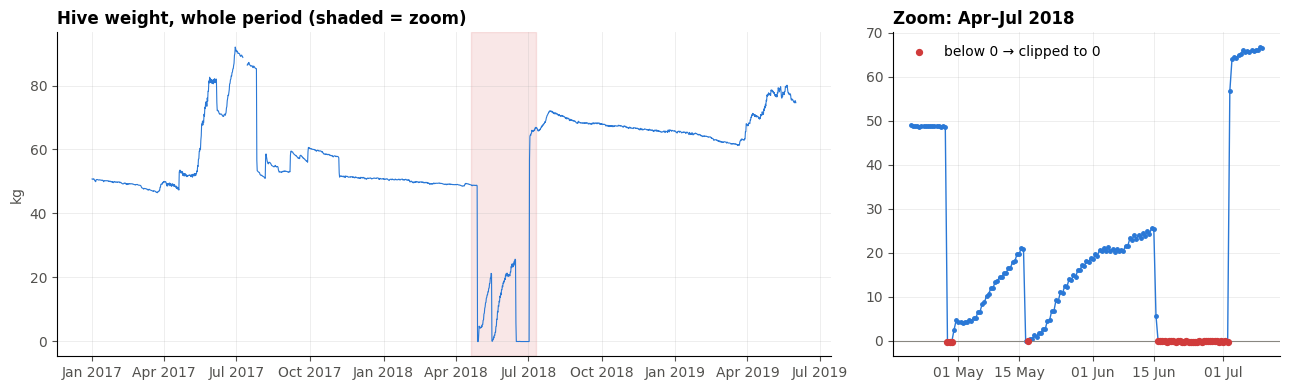

In [17]:
w_raw = typed['weight'].assign(timestamp=weight['timestamp'])
fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={'width_ratios': [2, 1]})
axes[0].plot(w_raw['timestamp'], w_raw['weight'] / 1000, color=BLUE, linewidth=0.8)
axes[0].axvspan(pd.Timestamp('2018-04-20', tz='UTC'), pd.Timestamp('2018-07-10', tz='UTC'), color=RED, alpha=0.12)
axes[0].set_title('Hive weight, whole period (shaded = zoom)'); axes[0].set_ylabel('kg')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

z = w_raw[(w_raw['timestamp'] >= pd.Timestamp('2018-04-20', tz='UTC')) & (w_raw['timestamp'] <= pd.Timestamp('2018-07-10', tz='UTC'))]
axes[1].plot(z['timestamp'], z['weight'] / 1000, color=BLUE, linewidth=1, marker='o', markersize=2.5)
negz = z[z['weight'] < 0]
axes[1].scatter(negz['timestamp'], negz['weight'] / 1000, color=RED, s=18, zorder=3, label='below 0 → clipped to 0')
axes[1].axhline(0, color=GREY, linewidth=0.8)
axes[1].set_title('Zoom: Apr–Jul 2018'); axes[1].legend(loc='upper left')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.tight_layout(); plt.show()

### Temperature: plausibility check
Negative temperatures (to −7 °C) appear **only in January–March**, and summer values reach ~37 °C (the brood nest is kept at ~35 °C).
Both are realistic for a sensor inside a hive, so nothing is removed. All values are Celsius, so no unit conversion is needed.

In [18]:
print(temperature.loc[temperature['temperature'] < 0, 'timestamp'].dt.month.value_counts().sort_index().rename('negative readings per month'))
print('outside -20..50 °C:', (~temperature['temperature'].between(-20, 50) & temperature['temperature'].notna()).sum())

timestamp
1     386
2    2077
3    1570
Name: negative readings per month, dtype: int64
outside -20..50 °C: 0


**Box plot per month.** A box plot summarises a distribution in one shape: the box holds the middle 50 % of readings,
the line inside is the median, and the whiskers show the normal range. Drawing one box per month lets us *compare distributions across categories*.
It shows the negatives only occur in cold months, and summer sits steadily around 35 °C (the bees heat the brood nest), so both are real.

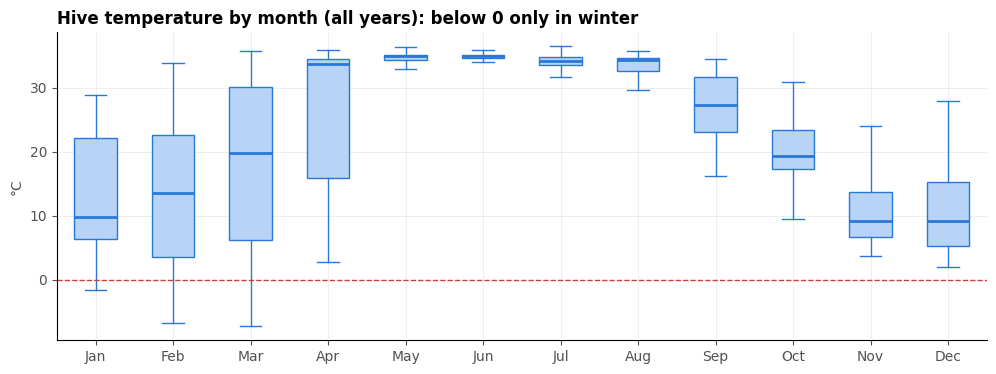

In [19]:
temp_month = temperature.dropna().assign(month=temperature['timestamp'].dt.month)
months = range(1, 13)
data = [temp_month.loc[temp_month['month'] == m, 'temperature'] for m in months]
fig, ax = plt.subplots(figsize=(12, 4))
ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.55,
           boxprops=dict(facecolor='#b7d3f6', color=BLUE), medianprops=dict(color=BLUE, linewidth=2),
           whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.axhline(0, color=RED, linewidth=1, linestyle='--')
ax.set_ylabel('°C'); ax.set_title('Hive temperature by month (all years): below 0 only in winter')
plt.show()

### Units & IDs
- temperature: °C · humidity: % · weight: grams · flow: bees per minute. Each measure uses a single unit.
- There's no hive-ID column; the location comes from the file name (`schwartau`). The gold notebook adds a `location` column when merging,
  so we keep the file naming convention `schwartau__<timestamp>.parquet` identical across all sensors.
- There are no boolean or categorical columns in these files, so those LMS checks don't apply here (they'll matter for weather data, e.g. `condition`).

## 7. Outliers
The LMS suggests z-scores or IQR. Let's test them on `flow_in` before trusting them.

In [20]:
fi = flow_clean['flow_in']
q1, q3 = fi.quantile([.25, .75]); iqr = q3 - q1
iqr_flags = (fi > q3 + 1.5 * iqr).sum()
z_flags = (((fi - fi.mean()) / fi.std()).abs() > 3).sum()
print(f"IQR rule   (> {q3 + 1.5*iqr:.0f} bees/min) would flag {iqr_flags:,} readings")
print(f"z-score > 3 (> {fi.mean() + 3*fi.std():.0f} bees/min) would flag {z_flags:,} readings")

IQR rule   (> 60 bees/min) would flag 175,748 readings
z-score > 3 (> 190 bees/min) would flag 31,045 readings


**Box plot + histogram with the candidate cut-offs.** The box plot is how the IQR rule "sees" the data: everything beyond the whisker is an outlier.
The histogram marks each rule's cut-off, so you can see how much normal data each one would throw away.

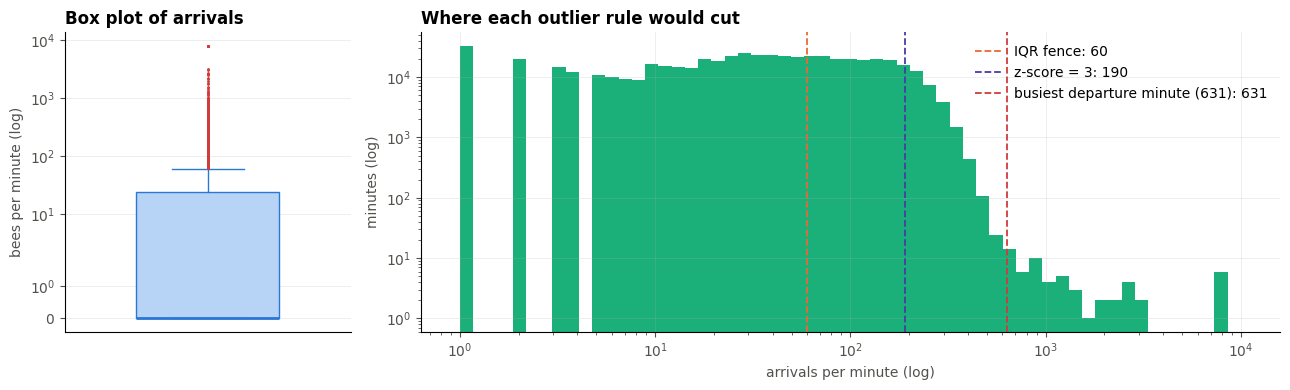

In [21]:
max_departure = flow_clean['flow_out'].abs().max()
fences = [(q3 + 1.5 * iqr, 'IQR fence', ORANGE),
          (fi.mean() + 3 * fi.std(), 'z-score = 3', '#4a3aa7'),
          (max_departure, f'busiest departure minute ({max_departure})', RED)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={'width_ratios': [1, 3]})
axes[0].boxplot(fi.dropna(), vert=True, widths=0.5, patch_artist=True,
                boxprops=dict(facecolor='#b7d3f6', color=BLUE), medianprops=dict(color=BLUE, linewidth=2),
                whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE),
                flierprops=dict(marker='.', markersize=2, markerfacecolor=RED, markeredgecolor=RED))
axes[0].set_yscale('symlog'); axes[0].set_xticks([]); axes[0].set_ylabel('bees per minute (log)')
axes[0].set_title('Box plot of arrivals')

axes[1].hist(fi.dropna(), bins=np.logspace(0, 4, 60), color=AQUA)
axes[1].set_xscale('log'); axes[1].set_yscale('log')
for x, label, c in fences:
    axes[1].axvline(x, color=c, linestyle='--', linewidth=1.3, label=f'{label}: {x:.0f}')
axes[1].set_xlabel('arrivals per minute (log)'); axes[1].set_ylabel('minutes (log)')
axes[1].set_title('Where each outlier rule would cut')
axes[1].legend(loc='upper right')
plt.tight_layout(); plt.show()

The box plot's whisker ends around 60 bees/min, so it calls thousands of perfectly normal busy minutes "outliers".
Only the red line separates the real distribution from the few isolated values out on the right.

**Why we don't use them here:** bee traffic is *zero most of the time* (nights, winter) and busy on sunny afternoons.
That's a very skewed distribution, so IQR/z-score would flag tens of thousands of perfectly normal busy minutes.
These methods assume roughly bell-shaped data. Instead we use **domain rules**:

1. **7999 is an error code, not a count.** It appears 6 times, surrounded by readings of 5–30 bees, and it's a suspicious "max value" (think `9999`).
2. **Every bee that arrives must have left first.** The busiest departure minute ever recorded is 631 bees.
   Arrival values above that are isolated spikes (50 of them), about 80 % at night (22:00–05:00 German time = 20:00–03:00 UTC in summer), **when bees don't fly**.

We set these to **NaN** (not delete the row), so the timestamp and the matching `flow_out` survive.

In [22]:
error_code = flow_clean['flow_in'] == 7999
spike = (flow_clean['flow_in'] > max_departure) & ~error_code

print('max departures in one minute:', max_departure)
print('7999 error codes:            ', error_code.sum())
print('other impossible spikes:     ', spike.sum())

max departures in one minute: 631
7999 error codes:             6
other impossible spikes:      50


**Bar charts by hour of day: when do the spikes happen?** Hour of day is a category (0–23), so a bar chart compares them.
Top: normal bee activity (average arrivals per minute). Bottom: when the suspicious values occurred.
We use **German local time** here because that's the sunrise/sunset rhythm the bees follow.

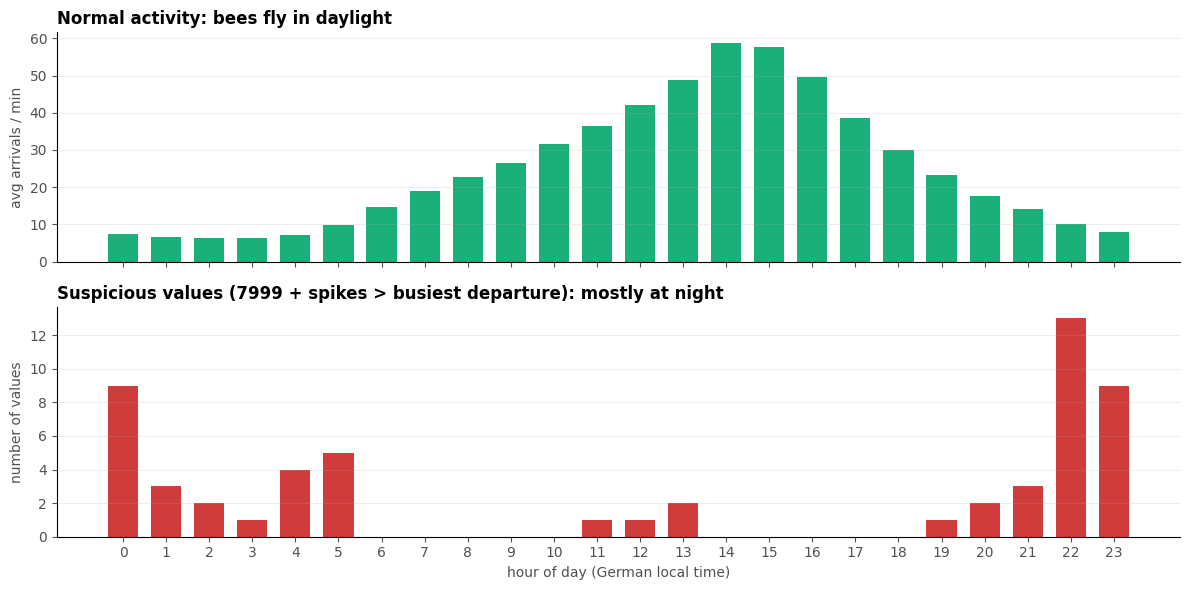

In [23]:
local_hour = flow_clean['timestamp'].dt.tz_convert(LOCAL_TZ).dt.hour
normal_by_hour = flow_clean.loc[~(error_code | spike), 'flow_in'].groupby(local_hour).mean()
bad_by_hour = local_hour[error_code | spike].value_counts().reindex(range(24), fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].bar(normal_by_hour.index, normal_by_hour.values, color=AQUA, width=0.7)
axes[0].set_ylabel('avg arrivals / min'); axes[0].set_title('Normal activity: bees fly in daylight')
axes[1].bar(bad_by_hour.index, bad_by_hour.values, color=RED, width=0.7)
axes[1].set_ylabel('number of values'); axes[1].set_title('Suspicious values (7999 + spikes > busiest departure): mostly at night')
axes[1].set_xlabel('hour of day (German local time)'); axes[1].set_xticks(range(24))
for ax in axes: ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

Activity and suspicious values happen at opposite times of day. That's strong evidence the spikes are sensor glitches, not real bees.

In [24]:
flow_clean.loc[error_code | spike, 'flow_in'] = np.nan
flow_clean[['flow_out', 'flow_in']] = flow_clean[['flow_out', 'flow_in']].astype('Int64')   # counts are whole numbers; Int64 allows NaN
print('max flow_in now:', flow_clean['flow_in'].max())

max flow_in now: 627


## 8. Duplicates and missing values
**Duplicates:** after UTC conversion there are no duplicate rows left, but we still run `drop_duplicates()` as a guard for future loads.

**Missing values: we keep them as NaN.** Why not fill or drop?
- **Interpolating** would *invent* readings. The humidity/weight gaps are a whole sensor outage (9–14 July 2017, same timestamps in both files),
  and interpolating 5 days of hive weight hides the fact that nobody measured it.
- **Dropping** the rows loses the information that a reading was *expected* at that time, which the analyst may need.
- Silver = trustworthy facts. Filling gaps is an *analysis decision*, made later in gold/analysis, where the analyst knows the purpose.

In [25]:
silver = {
    'flow': flow_clean,
    'humidity': humidity,
    'temperature': temperature,
    'weight': weight,
}
for name, df in silver.items():
    df = df.drop_duplicates().sort_values('timestamp').reset_index(drop=True)
    silver[name] = df
    print(f"{name:12s} rows={len(df):>9,}  missing values={df.drop(columns='timestamp').isna().sum().to_dict()}")

print('\nhumidity & weight gaps on identical timestamps:',
      silver['humidity'].loc[silver['humidity']['humidity'].isna(), 'timestamp'].reset_index(drop=True)
      .equals(silver['weight'].loc[silver['weight']['weight'].isna(), 'timestamp'].reset_index(drop=True)))

flow         rows=1,256,918  missing values={'flow_out': 0, 'flow_in': 56}
humidity     rows=    1,761  missing values={'humidity': 12}
temperature  rows=  253,430  missing values={'temperature': 2032}
weight       rows=    1,761  missing values={'weight': 12}

humidity & weight gaps on identical timestamps: True


In [26]:
# Gaps in time (not NaN values, but whole missing rows). Documented, not filled.
gaps = silver['flow']['timestamp'].diff()
print(gaps.value_counts().head(5))
silver['flow'].loc[gaps > pd.Timedelta('1h'), 'timestamp'].to_frame('first reading after a gap >1h')

timestamp
0 days 00:01:00    1256857
0 days 00:02:00         56
5 days 09:32:00          1
0 days 11:56:00          1
0 days 02:44:00          1
Name: count, dtype: int64


,first reading after a gap >1h
271556,2017-07-14 12:46:00+00:00
685868,2018-04-28 18:03:00+00:00
711317,2018-05-16 12:57:00+00:00
1138111,2019-03-10 00:01:00+00:00


**Bar chart: where in time is data missing?** One bar per month lets us see whether gaps are *scattered* (random dropouts, harmless)
or *clustered* (an outage, which the analyst needs to know about).

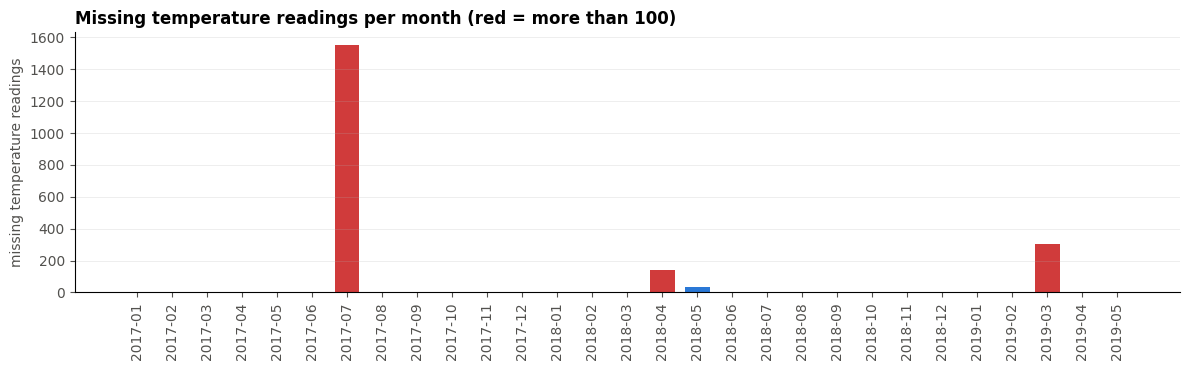

In [27]:
tmiss = silver['temperature'].assign(missing=silver['temperature']['temperature'].isna())
per_month = tmiss.groupby(tmiss['timestamp'].dt.strftime('%Y-%m'))['missing'].sum()

fig, ax = plt.subplots(figsize=(12, 3.8))
colors = [RED if v > 100 else BLUE for v in per_month.values]
ax.bar(per_month.index, per_month.values, color=colors, width=0.7)
ax.set_ylabel('missing temperature readings'); ax.set_title('Missing temperature readings per month (red = more than 100)')
ax.tick_params(axis='x', rotation=90); ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

Most months lose only a handful of readings (random dropouts), but a few months have large clusters: multi-day outages.
Interpolating across those would invent days of data, which is why silver keeps them as NaN.

## 9. Final validation
**Why:** "it ran without errors" isn't the same as "the data is right". These assertions encode every rule above,
so if a future bronze file breaks one, the notebook stops *before* writing bad data to silver.

In [28]:
for name, df in silver.items():
    assert str(df['timestamp'].dt.tz) == 'UTC', name
    assert df['timestamp'].is_unique, name
    assert df['timestamp'].is_monotonic_increasing, name
    assert all(re.fullmatch(r'[a-z0-9_]+', c) for c in df.columns), name

assert (silver['flow']['flow_out'].dropna() <= 0).all() and (silver['flow']['flow_in'].dropna() >= 0).all()
assert silver['humidity']['humidity'].dropna().between(0, 100).all()
assert (silver['weight']['weight'].dropna() >= 0).all()
assert silver['flow']['flow_in'].max() <= silver['flow']['flow_out'].abs().max()
print('All checks passed ✅')
{name: df.dtypes.astype(str).to_dict() for name, df in silver.items()}

All checks passed ✅


{'flow': {'timestamp': 'datetime64[us, UTC]',
  'flow_out': 'Int64',
  'flow_in': 'Int64'},
 'humidity': {'timestamp': 'datetime64[us, UTC]', 'humidity': 'float64'},
 'temperature': {'timestamp': 'datetime64[us, UTC]', 'temperature': 'float64'},
 'weight': {'timestamp': 'datetime64[us, UTC]', 'weight': 'float64'}}

### 9b. A first look at the clean silver data
Now the data is trustworthy, we can do what the analysts will do next. The four sensors are recorded at very different rates
(1 min, 5 min, 12 h), so we first bring them to a common **daily** level. That's an *analysis* step, so it happens in memory here and is **not** saved to silver.

**Small-multiple line charts, one per measure, sharing the time axis.** Each measure has its own unit (bees, °C, %, kg),
so we never put them on one axis. Stacking them with a shared date axis lets you compare seasons across all four.

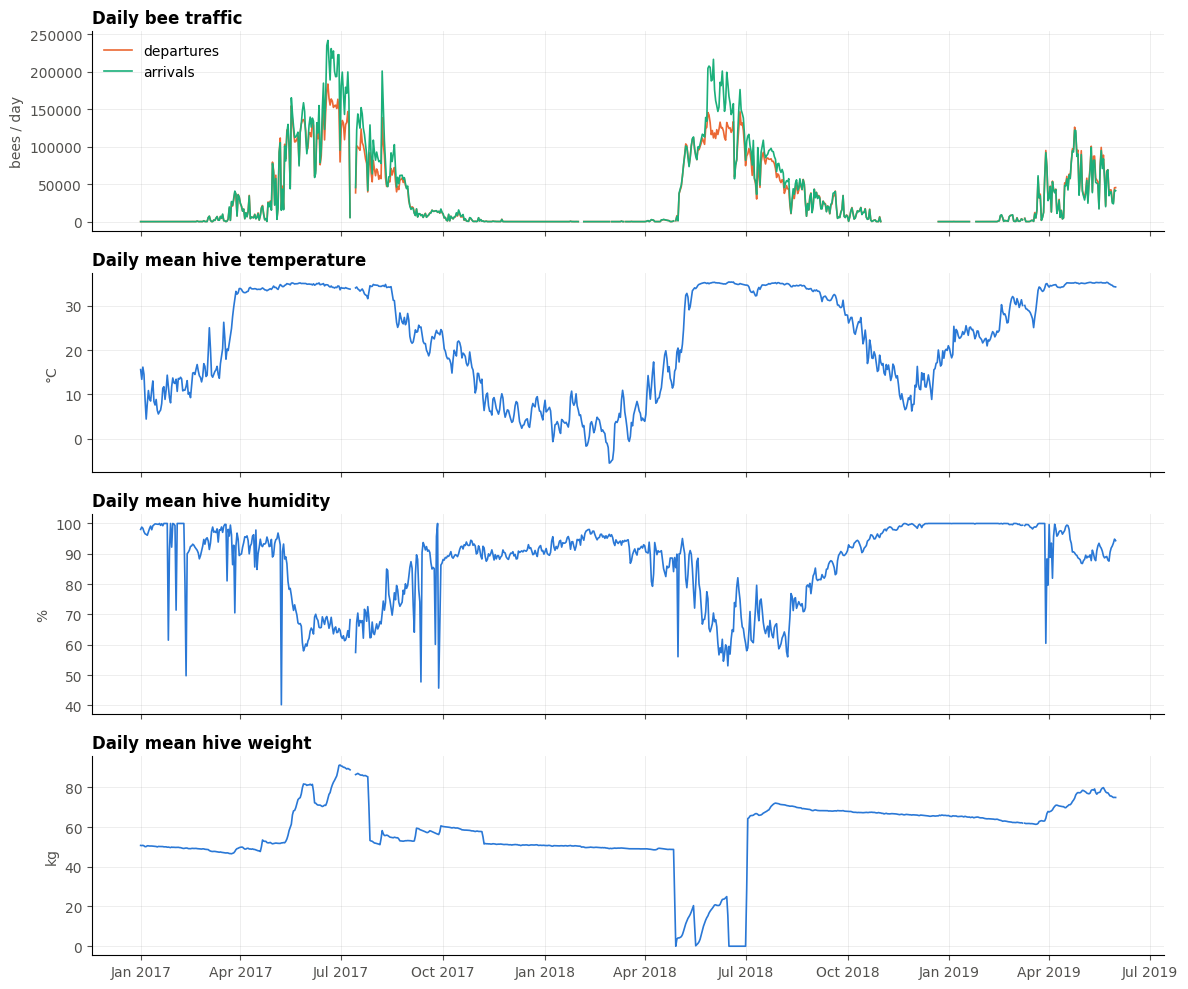

In [29]:
def daily(name, how):
    s = silver[name].set_index('timestamp')
    return s.resample('D').agg(how)

daily_df = pd.concat([
    daily('flow', 'sum').rename(columns={'flow_out': 'bees_out', 'flow_in': 'bees_in'}).assign(bees_out=lambda d: d['bees_out'].abs()),
    daily('temperature', 'mean').rename(columns={'temperature': 'hive_temp_c'}),
    daily('humidity', 'mean').rename(columns={'humidity': 'hive_humidity_pct'}),
    (daily('weight', 'mean') / 1000).rename(columns={'weight': 'hive_weight_kg'}),
], axis=1)
# a day with no flow rows at all sums to 0 → treat as missing instead
daily_df.loc[daily_df[['bees_in', 'bees_out']].sum(axis=1) == 0, ['bees_in', 'bees_out']] = np.nan

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(daily_df.index, daily_df['bees_out'], color=ORANGE, label='departures')
axes[0].plot(daily_df.index, daily_df['bees_in'], color=AQUA, label='arrivals')
axes[0].set_ylabel('bees / day'); axes[0].set_title('Daily bee traffic'); axes[0].legend(loc='upper left')
for ax, col, unit, title in [(axes[1], 'hive_temp_c', '°C', 'Daily mean hive temperature'),
                             (axes[2], 'hive_humidity_pct', '%', 'Daily mean hive humidity'),
                             (axes[3], 'hive_weight_kg', 'kg', 'Daily mean hive weight')]:
    ax.plot(daily_df.index, daily_df[col], color=BLUE)
    ax.set_ylabel(unit); ax.set_title(title)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout(); plt.show()

Clear seasonal patterns: traffic and hive temperature rise together in spring and summer, and weight grows over the summer as honey comes in.
Departures and arrivals track each other closely (correlation 0.98), a good sign both directions are counted consistently. Arrivals read a bit higher on peak days, a calibration detail worth mentioning to the analysts.

**Correlation heatmap: which measures move together?** Correlation runs from −1 (opposite) through 0 (unrelated) to +1 (together).
A heatmap shows every pair at once, so it's a quick way to decide which relationships are worth analysing, e.g. once the weather data is joined.

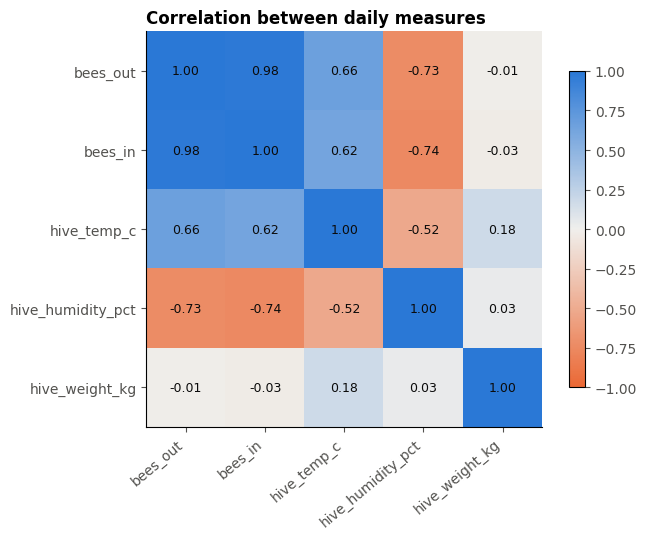

In [30]:
corr = daily_df.corr()
cmap = LinearSegmentedColormap.from_list('div', [ORANGE, '#f0efec', BLUE])
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=40, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9, color='#0b0b0b')
ax.grid(False); ax.set_title('Correlation between daily measures')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

What the heatmap tells us:
- **Traffic ↔ hive temperature: +0.66.** Bees fly more when the colony is warm (spring and summer).
- **Traffic ↔ hive humidity: −0.74.** The hive gets *drier* on busy days, probably because the bees fan their wings to dry nectar into honey. That's an interesting lead for analysis.
- **Weight ↔ anything: about 0.** Weight is a *running total* (it builds up over weeks), so comparing its daily level with daily traffic is the wrong question.
  The analyst should use the **daily change in weight** instead. Choosing the right measure matters as much as choosing the right chart.

**Scatter plot: hive temperature vs bee traffic.** A scatter plot shows the relationship behind a single correlation number: its shape, not just its strength.

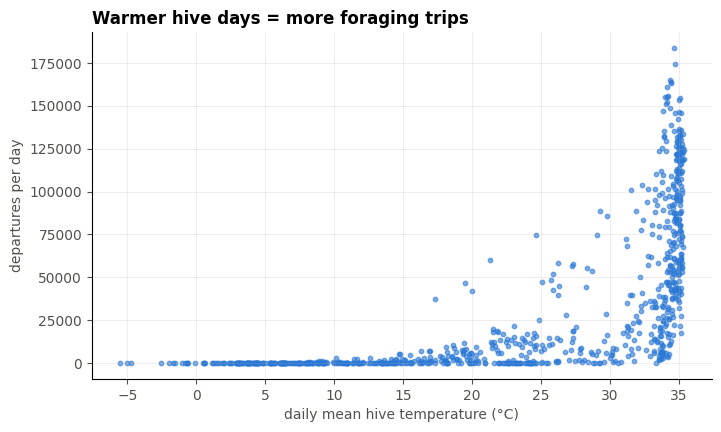

In [31]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(daily_df['hive_temp_c'], daily_df['bees_out'], s=10, color=BLUE, alpha=0.6)
ax.set_xlabel('daily mean hive temperature (°C)'); ax.set_ylabel('departures per day')
ax.set_title('Warmer hive days = more foraging trips')
plt.show()

Below about 20 °C there is almost no traffic; above it, traffic rises steeply. It's not a straight line, which is worth knowing before anyone fits a linear model.
Once the **weather** data is joined in the gold layer, the same charts with *outside* temperature, sunshine and rain become the core of the analysis.

## 10. Write to silver as Parquet
**Why Parquet instead of CSV:** it's columnar and compressed (much smaller: flow drops from ~57 MB to a few MB),
it's much faster to query, and, crucially, it **stores the data types**. The UTC timezone and the integer types survive,
whereas a CSV would turn everything back into text.

Files are saved as `silver/<sensor>/schwartau__<run time>.parquet`,
so the weather notebook (which reads the min/max timestamps from these files) and the Silver→Gold notebook work unchanged.
The run time in the file name means re-running never overwrites an earlier version.

In [32]:
run_stamp = pd.Timestamp.now().strftime('%Y-%m-%dT%Hh%Mm%Ss')
written = {}
for name, df in silver.items():
    out_dir = SILVER / name
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / f'{PLACE}__{run_stamp}.parquet'
    df.to_parquet(path, index=False)
    written[name] = path
    print(f'{str(path):55s} {path.stat().st_size/1e6:6.2f} MB')

../silver/flow/schwartau__2026-10-08T22h40m04s.parquet    9.42 MB
../silver/humidity/schwartau__2026-10-08T22h40m04s.parquet   0.02 MB
../silver/temperature/schwartau__2026-10-08T22h40m04s.parquet   2.23 MB
../silver/weight/schwartau__2026-10-08T22h40m04s.parquet   0.03 MB


In [33]:
# Read one back to prove the types survived the round-trip
check = pd.read_parquet(written['flow'])
print(check.dtypes); check.head()

timestamp    datetime64[us, UTC]
flow_out                   Int64
flow_in                    Int64
dtype: object


,timestamp,flow_out,flow_in
0,2017-01-01 13:15:00+00:00,0,0
1,2017-01-01 13:16:00+00:00,0,0
2,2017-01-01 13:17:00+00:00,0,0
3,2017-01-01 13:18:00+00:00,0,0
4,2017-01-01 13:19:00+00:00,0,0


In [34]:
# Date range that the weather notebook will request from the BrightSky API
start_date = min(df['timestamp'].min() for df in silver.values())
end_date   = max(df['timestamp'].max() for df in silver.values())
start_date, end_date

(Timestamp('2017-01-01 12:00:00+0000', tz='UTC'),
 Timestamp('2019-05-31 12:15:00+0000', tz='UTC'))

## Summary of decisions

| Issue found | Decision | Reason |
|---|---|---|
| Timestamps stored as text | `pd.to_datetime` | Needed for sorting, joining, timezone maths |
| Local German time with DST | Convert to UTC (`infer` for dense data, `True` for 12-hourly) | Removes the October duplicate hour; matches the weather API |
| Flow file = 2 stacked series | Split into `flow_out` / `flow_in` | One timestamp, one row, clear meaning |
| 697k "duplicates" in raw flow | **Not** dropped | They are real zero counts from the two halves |
| Negative humidity (−100 next to 100) | `.abs()` | Sign-flip sensor error |
| Negative weight (≈ −170 g on empty scale) | Clip to 0 | A scale can't weigh less than nothing |
| Negative temperatures in winter | Kept | Physically realistic |
| `flow_in` = 7999 | NaN | Sensor error code |
| `flow_in` > busiest departure minute (mostly at night) | NaN | Physically impossible spikes |
| IQR / z-score | Tested, not used | Flow is extremely skewed; they'd flag normal busy minutes |
| Missing values & time gaps | Kept as NaN | Silver shouldn't invent data; filling is an analysis decision |
| CSV | Parquet | Smaller, faster, keeps data types incl. UTC |